# Revenue Forecasting — model selection & calibrated uncertainty

This notebook reproduces how Profitly chooses its forecast model. It imports
the **production code** (`app.services.forecast`) and runs it on the channel's
daily revenue, so the notebook *is* the evaluation behind the served model — not
a parallel reimplementation.

Thesis: on a short, seasonal, low-volume series you should **benchmark a ladder
and let the data pick** — and a *damped* Holt-Winters ETS wins, beating both the
naive baseline and a gradient-boosted model.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str((ROOT.parent / "backend").resolve()))
DATA = ROOT / "data"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})
ACCENT, INK = "#b8530e", "#1a1712"

from app.services.forecast.conformal import empirical_coverage, rolling_backtest  # noqa: E402
from app.services.forecast.models import (  # noqa: E402
    ETSForecaster, LightGBMForecaster, NaiveForecaster, SeasonalNaiveForecaster,
)
from app.services.forecast.service import forecast_revenue  # noqa: E402

## Build the daily revenue series
Aggregate to channel-level daily revenue and gap-fill to a continuous index
(the same preprocessing the production loader does).

In [2]:
daily = pd.read_csv(DATA / "daily_analytics.csv", parse_dates=["date"])
s = daily.groupby("date").revenue_usd.sum()
y = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="D"), fill_value=0.0)
print(f"{len(y)} days, mean ${y.mean():.2f}/day, std ${y.std():.2f}")
y.tail()

90 days, mean $8.08/day, std $2.93


2026-05-24    3.5410
2026-05-25    7.7947
2026-05-26    6.4104
2026-05-27    5.9984
2026-05-28    6.2810
Freq: D, Name: revenue_usd, dtype: float64

## The model ladder, scored by walk-forward CV
`rolling_backtest` does expanding-window rolling-origin evaluation. We score
every model at 7- and 14-day horizons on MAE, MAPE, and interval coverage.

In [3]:
models = {
    "naive": NaiveForecaster,
    "seasonal_naive": SeasonalNaiveForecaster,
    "ets (damped)": ETSForecaster,
    "lightgbm": LightGBMForecaster,
}
rows = []
for name, cls in models.items():
    for H in (7, 14):
        bt = rolling_backtest(y, lambda c=cls: c(), horizon=H)
        rows.append({
            "model": name, "H": H, "MAE": round(bt.mae, 3),
            "MAPE%": round(bt.mape, 1), "coverage": empirical_coverage(bt),
        })
results = pd.DataFrame(rows)
results

,model,H,MAE,MAPE%,coverage
0,naive,7,1.344,22.2,0.971
1,naive,14,1.617,29.0,0.983
2,seasonal_naive,7,1.585,27.4,1.000
3,seasonal_naive,14,1.788,32.3,1.000
4,ets (damped),7,1.178,19.7,0.971
5,ets (damped),14,1.463,26.3,0.983
6,lightgbm,7,1.552,27.7,1.000
7,lightgbm,14,1.806,33.8,0.996


**Reading the table:** damped ETS has the lowest MAE at *both* horizons.
LightGBM overfits ~90 points and loses to the naive baseline — documenting that
the complex model doesn't help here is the point of the benchmark, not a
failure. Coverage sits a touch above the 90% nominal (conservative intervals).

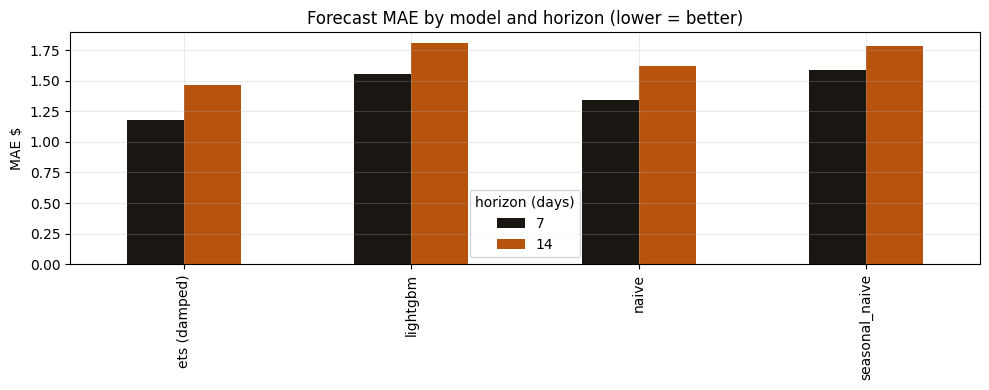

In [4]:
piv = results.pivot(index="model", columns="H", values="MAE")
ax = piv.plot(kind="bar", color=[INK, ACCENT])
ax.set(title="Forecast MAE by model and horizon (lower = better)", ylabel="MAE $", xlabel="")
ax.legend(title="horizon (days)")
plt.tight_layout(); plt.show()

## Why damping matters
An *undamped* additive trend extrapolates the day-60 level shift downward and
loses to naive at H=14; damping reins the projection back toward the recent
level. We confirm it directly:

In [5]:
class _UndampedETS(ETSForecaster):
    def fit(self, series):
        from statsmodels.tsa.holtwinters import ExponentialSmoothing
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self._fit = ExponentialSmoothing(
                series.to_numpy(float), trend="add", damped_trend=False,
                seasonal="add", seasonal_periods=7, initialization_method="estimated",
            ).fit()

damped = rolling_backtest(y, ETSForecaster, 14).mae
undamped = rolling_backtest(y, _UndampedETS, 14).mae
naive = rolling_backtest(y, NaiveForecaster, 14).mae
print(f"H=14 MAE  damped ETS={damped:.3f}  undamped ETS={undamped:.3f}  naive={naive:.3f}")

H=14 MAE  damped ETS=1.463  undamped ETS=1.647  naive=1.617


## The served forecast + conformal interval
`forecast_revenue` selects the winner, fits it on the full series, and attaches
horizon-wise split-conformal bands (per-horizon residual quantiles → the band
widens with the horizon, no distributional assumption).

C:\Users\aaqui\OneDrive\Desktop\CreatorAnalytics\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


selected model: ets | backtest: 1.463 MAE | beats_naive: True


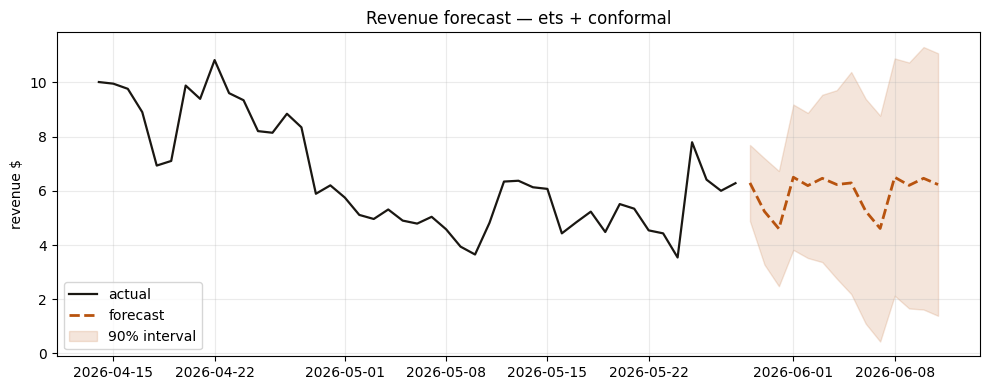

In [6]:
out = forecast_revenue(y, horizon=14)
hist = pd.DataFrame(out["history"]); hist["date"] = pd.to_datetime(hist["date"])
fc = pd.DataFrame(out["forecast"]); fc["date"] = pd.to_datetime(fc["date"])
print("selected model:", out["model"], "| backtest:", out["backtest"]["mae"],
      "MAE | beats_naive:", out["backtest"]["beats_naive"])

fig, ax = plt.subplots()
ax.plot(hist.date.tail(45), hist.value.tail(45), color=INK, lw=1.6, label="actual")
ax.plot(fc.date, fc.yhat, color=ACCENT, ls="--", lw=2, label="forecast")
ax.fill_between(fc.date, fc.lower, fc.upper, color=ACCENT, alpha=0.15, label="90% interval")
ax.set(title=f"Revenue forecast — {out['model']} + conformal", ylabel="revenue $", xlabel="")
ax.legend()
plt.tight_layout(); plt.show()

## Takeaways
- **Damped Holt-Winters ETS** is selected: MAE ~$1.46 at 14 days, ~10% better
  than naive; LightGBM overfits and loses.
- **Damping** is the decisive ingredient given the mid-series level shift.
- Uncertainty is **calibrated conformal intervals**, not a single optimistic
  line — coverage is verified out-of-sample.